In [ ]:
import re, glob
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

experiments = {
    'batch_2': '/content/drive/My Drive/queue-wait-vs-arrival-rate/batch_2_results/batch_2_*.txt',
    'batch_4': '/content/drive/My Drive/queue-wait-vs-arrival-rate/batch_4_results/batch_4_*.txt',
    'batch_8': '/content/drive/My Drive/queue-wait-vs-arrival-rate/batch_8_results/batch_8_*.txt',
    'batch_16': '/content/drive/My Drive/queue-wait-vs-arrival-rate/batch_16_results/batch_16_*.txt',
}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def parse_perf_file(filepath):
    with open(filepath, 'r') as f:
        text = f.read()

    # split into blocks, each starting with "Request Rate:"
    blocks = re.split(r'(?=Request Rate: \d)', text)

    results = []
    for block in blocks:
        if 'Request Rate:' not in block:
            continue

        m = re.search(r'Request Rate: ([\d.]+) inference', block)
        request_rate = float(m.group(1)) if m else None

        m = re.search(r'Throughput: ([\d.]+) infer/sec', block)
        throughput = float(m.group(1)) if m else None

        m = re.search(r'queue (\d+) usec', block)
        queue_time_ms = int(m.group(1)) / 1000 if m else None

        m = re.search(r'compute infer (\d+) usec', block)
        compute_infer_ms = int(m.group(1)) / 1000 if m else None

        m_infer = re.search(r'Inference count: (\d+)', block)
        m_exec  = re.search(r'Execution count: (\d+)', block)
        avg_batch_size = None
        if m_infer and m_exec:
            infer = int(m_infer.group(1))
            execc = int(m_exec.group(1))
            avg_batch_size = round(infer / execc, 3) if execc > 0 else None

        unstable = 'not stabilizing' in block.lower() or 'were delayed' in block

        if request_rate:
            results.append({
                'request_rate': request_rate,
                'throughput': throughput,
                'queue_time_ms': queue_time_ms,
                'compute_infer_ms': compute_infer_ms,
                'avg_batch_size': avg_batch_size,
                'unstable': unstable
            })

    return results



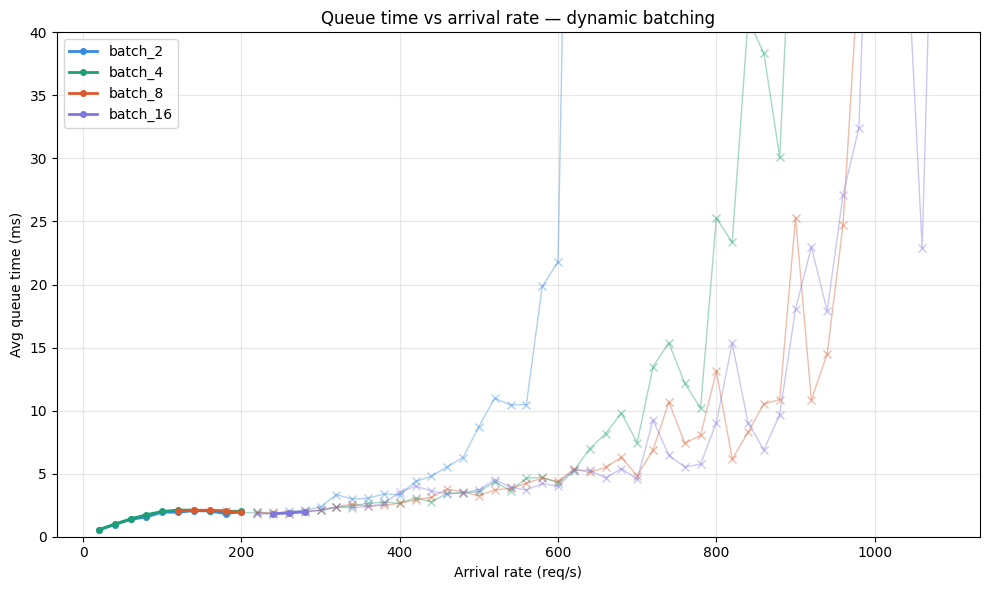

In [ ]:

colors = {
    'batch_2':  '#378ADD',
    'batch_4':  '#1D9E75',
    'batch_8':  '#D85A30',
    'batch_16': '#7F77DD',
}

fig, ax = plt.subplots(figsize=(10, 6))

for label, pattern in experiments.items():
    all_results = []
    for f in glob.glob(pattern):
        all_results.extend(parse_perf_file(f))
    results = sorted(all_results, key=lambda r: r['request_rate'])
    results = results[:-1]  # drop last point

    stable   = [r for r in results if not r['unstable']]
    unstable = [r for r in results if r['unstable']]

    ax.plot([r['request_rate'] for r in stable],
            [r['queue_time_ms'] for r in stable],
            'o-', color=colors[label], label=label, linewidth=2, markersize=4)
    ax.plot([r['request_rate'] for r in unstable],
            [r['queue_time_ms'] for r in unstable],
            'x-', color=colors[label], alpha=0.4, linewidth=1)

ax.set_xlabel('Arrival rate (req/s)')
ax.set_ylabel('Avg queue time (ms)')
ax.set_title('Queue time vs arrival rate — dynamic batching')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 40)
plt.tight_layout()
plt.savefig('queue_vs_rate_combined.png', dpi=150)
plt.show()

In [ ]:
# --- Tables with rho for each batch size ---

for label, pattern in experiments.items():
    all_results = []
    for f in glob.glob(pattern):
        all_results.extend(parse_perf_file(f))
    results = sorted(all_results, key=lambda r: r['request_rate'])
    results = results[:-1]  # drop last point

    # estimate mu from low-load compute infer times (first 5 stable points)
    stable = [r for r in results if not r['unstable'] and r['compute_infer_ms'] is not None]
    mu = 1000 / np.mean([r['compute_infer_ms'] for r in stable[:5]])  # req/sec
    B = int(label.split('_')[1])  # extract batch size from label
    mu_eff = mu * B  # effective service rate with batching

    print(f"\n{'='*80}")
    print(f"  {label}   (mu={mu:.1f} req/s, mu_eff=mu*B={mu_eff:.1f} req/s, B={B})")
    print(f"{'='*80}")
    print(f"{'Request Rate':>14} {'Queue Time (ms)':>16} {'Compute Infer (ms)':>20} {'Avg Batch Size':>16} {'rho':>8} {'Stable':>8}")
    print("-" * 86)

    for r in results:
        lam = r['request_rate']
        rho = lam / mu_eff  # utilization = lambda / (mu * B)

        qt      = f"{r['queue_time_ms']:>16.3f}"    if r['queue_time_ms']    is not None else f"{'N/A':>16}"
        ci      = f"{r['compute_infer_ms']:>20.3f}" if r['compute_infer_ms'] is not None else f"{'N/A':>20}"
        bs      = f"{r['avg_batch_size']:>16.3f}"   if r['avg_batch_size']   is not None else f"{'N/A':>16}"
        rho_str = f"{rho:>8.3f}"
        stable_str = 'No' if r['unstable'] else 'Yes'

        print(f"{lam:>14.1f} {qt} {ci} {bs} {rho_str} {stable_str:>8}")


  batch_2   (mu=188.1 req/s, mu_eff=mu*B=376.2 req/s, B=2)
  Request Rate  Queue Time (ms)   Compute Infer (ms)   Avg Batch Size      rho   Stable
--------------------------------------------------------------------------------------
          20.0            0.536                5.400            1.012    0.053      Yes
          40.0            0.960                5.446            1.009    0.106      Yes
          60.0            1.374                5.390            1.022    0.159      Yes
          80.0            1.568                5.237            1.049    0.213      Yes
         100.0            1.950                5.106            1.089    0.266      Yes
         120.0            1.942                4.549            1.096    0.319      Yes
         140.0            2.069                4.380            1.118    0.372      Yes
         160.0            2.040                4.043            1.130    0.425      Yes
         180.0            1.835                3.563         